In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA

In [3]:
df = pd.read_csv("bnpl_dataset.csv")

df.head()

,Transaction_ID,Customer_Age,Gender,Annual_Income,Credit_Score,Purchase_Category,BNPL_Provider,Purchase_Amount,Repayment_Status
0,6cbfd4e5-8e91-4a7b-8a14-e3dfa86a3359,56,Male,32293,353,Beauty,Sezzle,249,Defaulted
1,863e8aa6-847e-4ae0-b96b-65241f3450a2,46,Male,72774,354,Groceries,Affirm,188,Paid On Time
2,a24efee2-16f2-42dc-a0e7-6df4960df0b8,32,Male,82207,630,Travel,Sezzle,1610,Paid On Time
3,bbad847a-a92f-4766-ba3f-98b9b199b4cf,60,Male,92498,470,Fashion,Sezzle,120,Paid On Time
4,3f1b1928-09ca-4d06-8ec3-4efd3468d0ec,25,Male,32060,502,Travel,Klarna,1849,Paid On Time


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Transaction_ID     50000 non-null  object
 1   Customer_Age       50000 non-null  int64 
 2   Gender             50000 non-null  object
 3   Annual_Income      50000 non-null  int64 
 4   Credit_Score       50000 non-null  int64 
 5   Purchase_Category  50000 non-null  object
 6   BNPL_Provider      50000 non-null  object
 7   Purchase_Amount    50000 non-null  int64 
 8   Repayment_Status   50000 non-null  object
dtypes: int64(4), object(5)
memory usage: 3.4+ MB


In [6]:
df.isnull().sum()

,0
Transaction_ID,0
Customer_Age,0
Gender,0
Annual_Income,0
Credit_Score,0
Purchase_Category,0
BNPL_Provider,0
Purchase_Amount,0
Repayment_Status,0


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.describe()

,Customer_Age,Annual_Income,Credit_Score,Purchase_Amount
count,50000.000000,50000.000000,50000.000000,50000.000000
mean,40.979240,69980.860200,573.569300,563.221980
std,13.528733,28923.444012,158.853766,706.078491
min,18.000000,20000.000000,300.000000,20.000000
25%,29.000000,44915.500000,435.000000,124.000000
50%,41.000000,70071.500000,572.000000,229.000000
75%,53.000000,95262.250000,711.000000,785.000000
max,64.000000,119998.000000,849.000000,2999.000000


In [9]:
df = df.fillna(df.median(numeric_only=True))

In [10]:
df = df.fillna(df.mode().iloc[0])

In [11]:
df.isnull().sum()

,0
Transaction_ID,0
Customer_Age,0
Gender,0
Annual_Income,0
Credit_Score,0
Purchase_Category,0
BNPL_Provider,0
Purchase_Amount,0
Repayment_Status,0


In [12]:
numerical_cols = df.select_dtypes(include=np.number).columns

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower) & (df[col] <= upper)]

In [13]:
minmax = MinMaxScaler()

df_minmax = df.copy()
df_minmax[numerical_cols] = minmax.fit_transform(df[numerical_cols])

df_minmax.head()

,Transaction_ID,Customer_Age,Gender,Annual_Income,Credit_Score,Purchase_Category,BNPL_Provider,Purchase_Amount,Repayment_Status
0,6cbfd4e5-8e91-4a7b-8a14-e3dfa86a3359,0.826087,Male,0.122889,0.096539,Beauty,Sezzle,0.130410,Defaulted
1,863e8aa6-847e-4ae0-b96b-65241f3450a2,0.608696,Male,0.527727,0.098361,Groceries,Affirm,0.095672,Paid On Time
2,a24efee2-16f2-42dc-a0e7-6df4960df0b8,0.304348,Male,0.622064,0.601093,Travel,Sezzle,0.905467,Paid On Time
3,bbad847a-a92f-4766-ba3f-98b9b199b4cf,0.913043,Male,0.724981,0.309654,Fashion,Sezzle,0.056948,Paid On Time
5,f99db9dc-9e5c-40d1-918a-ecd3469e8c17,0.434783,Female,0.748332,0.872495,Travel,Klarna,0.621868,Paid On Time


In [14]:
scaler = StandardScaler()

df_zscore = df.copy()
df_zscore[numerical_cols] = scaler.fit_transform(df[numerical_cols])

df_zscore.head()

,Transaction_ID,Customer_Age,Gender,Annual_Income,Credit_Score,Purchase_Category,BNPL_Provider,Purchase_Amount,Repayment_Status
0,6cbfd4e5-8e91-4a7b-8a14-e3dfa86a3359,1.109881,Male,-1.303178,-1.386086,Beauty,Sezzle,-0.301729,Defaulted
1,863e8aa6-847e-4ae0-b96b-65241f3450a2,0.370282,Male,0.095976,-1.379791,Groceries,Affirm,-0.439762,Paid On Time
2,a24efee2-16f2-42dc-a0e7-6df4960df0b8,-0.665156,Male,0.422011,0.357600,Travel,Sezzle,2.777992,Paid On Time
3,bbad847a-a92f-4766-ba3f-98b9b199b4cf,1.405721,Male,0.777702,-0.649583,Fashion,Sezzle,-0.593635,Paid On Time
5,f99db9dc-9e5c-40d1-918a-ecd3469e8c17,-0.221397,Female,0.858407,1.295539,Travel,Klarna,1.651099,Paid On Time


In [15]:
pca = PCA()

pca_data = pca.fit_transform(df_zscore[numerical_cols])

explained_variance = pca.explained_variance_ratio_

explained_variance

array([0.25232491, 0.25041922, 0.24923018, 0.24802569])

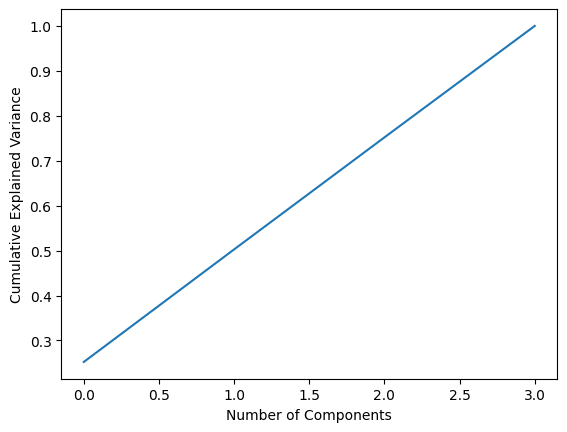

In [16]:
plt.figure()
plt.plot(np.cumsum(explained_variance))
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.show()